## Exploratory Data Analysis

In [1]:
# Import libraries
import pandas as pd
pd.set_option('display.max_columns', 100)

import numpy as np

# matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# import dataset
df = pd.read_csv('./flights_cleaned_df.csv')
df.sample(5)

,origin,City,destination,City_destination,distance_km,Name_airline,aircraft,query_date,departure_date,departure_clock_time,day_of_week_departure,month_departure,arrival_date,arrival_clock_time,days_until_departure,trip_duration_minutes,number_of_stops,bookable_seats,base_price
22284,YYZ,Toronto,YVR,Vancouver,3345.516314,WestJet,7M8,2026-03-08,2026-06-28,12:00:00,6,6,2026-06-28,14:14:00,112,314,0,7,137
18395,YOW,Ottawa,YYC,Calgary,2878.682577,WestJet,73H,2026-03-08,2026-04-19,05:40:00,6,4,2026-04-19,12:32:00,42,353,1,7,105
25017,YYZ,Toronto,YYC,Calgary,2689.246727,WestJet,73W,2026-03-08,2026-05-10,08:00:00,6,5,2026-05-10,16:25:00,63,293,1,7,74
15386,YOW,Ottawa,YYZ,Toronto,363.703036,Air Canada,223,2026-03-08,2026-03-08,12:05:00,6,3,2026-03-08,13:25:00,0,80,0,9,364
23971,YYZ,Toronto,YVR,Vancouver,3345.516314,WestJet,7M8,2026-03-08,2026-10-04,15:30:00,6,10,2026-10-04,22:25:00,210,357,1,7,137


Build a heatmap to visualize correlations between our numberic features.

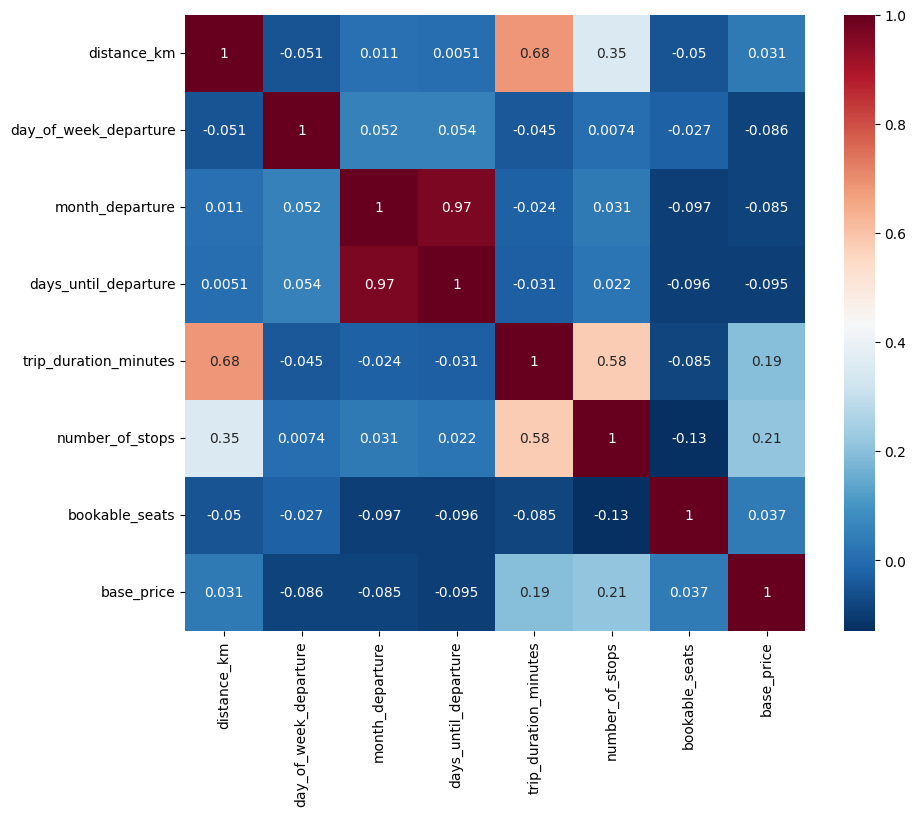

In [3]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.show()

Observe categorical columns.

c:\Users\Razak\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


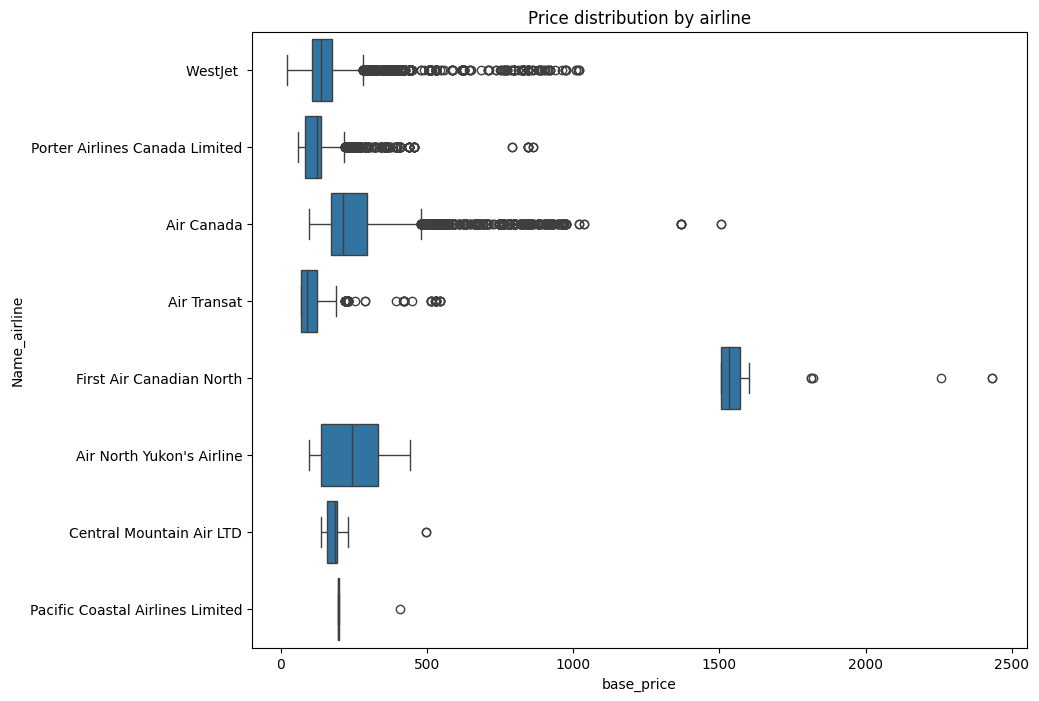

In [4]:
plt.figure(figsize=(10,8))
sns.boxplot(data = df, y = 'Name_airline', x = 'base_price')
plt.title('Price distribution by airline')
plt.show()

we can drop teh First Air Canadian North airline as it is an outlier and can skew predictions.

In [5]:
print(f'Number of flights for First Air Canadian North: {df[df["Name_airline"] == "First Air Canadian North"].shape[0]}')
df.groupby('Name_airline')['base_price'].mean().reset_index()

Number of flights for First Air Canadian North: 85


,Name_airline,base_price
0,Air Canada,248.999504
1,Air North Yukon's Airline,230.075949
2,Air Transat,126.219067
3,Central Mountain Air LTD,192.385965
4,First Air Canadian North,1572.823529
5,Pacific Coastal Airlines Limited,230.666667
6,Porter Airlines Canada Limited,132.679868
7,WestJet,154.316473


We can drop as it is < 2% of our dataset.

In [6]:
# drop rows with first air canadian north 
df.drop(df[df['Name_airline'] == 'First Air Canadian North'].index, inplace=True)

### 1. Price Distribution Analysis
Business Questions

- Which airline offers the lowest average price per route?
- Are there premium airlines on short routes?
- What is the typical price spread on a route?
- Are there pricing outliers that suggest premium or error fares?


In [7]:
# typcal price spread on a route
route_df = df.groupby(['origin','City','destination','City_destination']).agg(base_price = ('base_price', 'mean'),
                                                                              flight_count = ('base_price', 'count')
                                                                              ).reset_index()
route_df['route'] = route_df['City'] + '-' + route_df['City_destination']

# airline offers the lowest average price
airline_price =df.groupby('Name_airline')['base_price'].mean().reset_index()

# airline offers the lowest average price per route
airline_route_price = df.groupby(['origin','City','destination','City_destination','Name_airline'])['base_price'].mean().reset_index()
airline_route_price['route'] = airline_route_price['City'] + '-' + airline_route_price['City_destination']

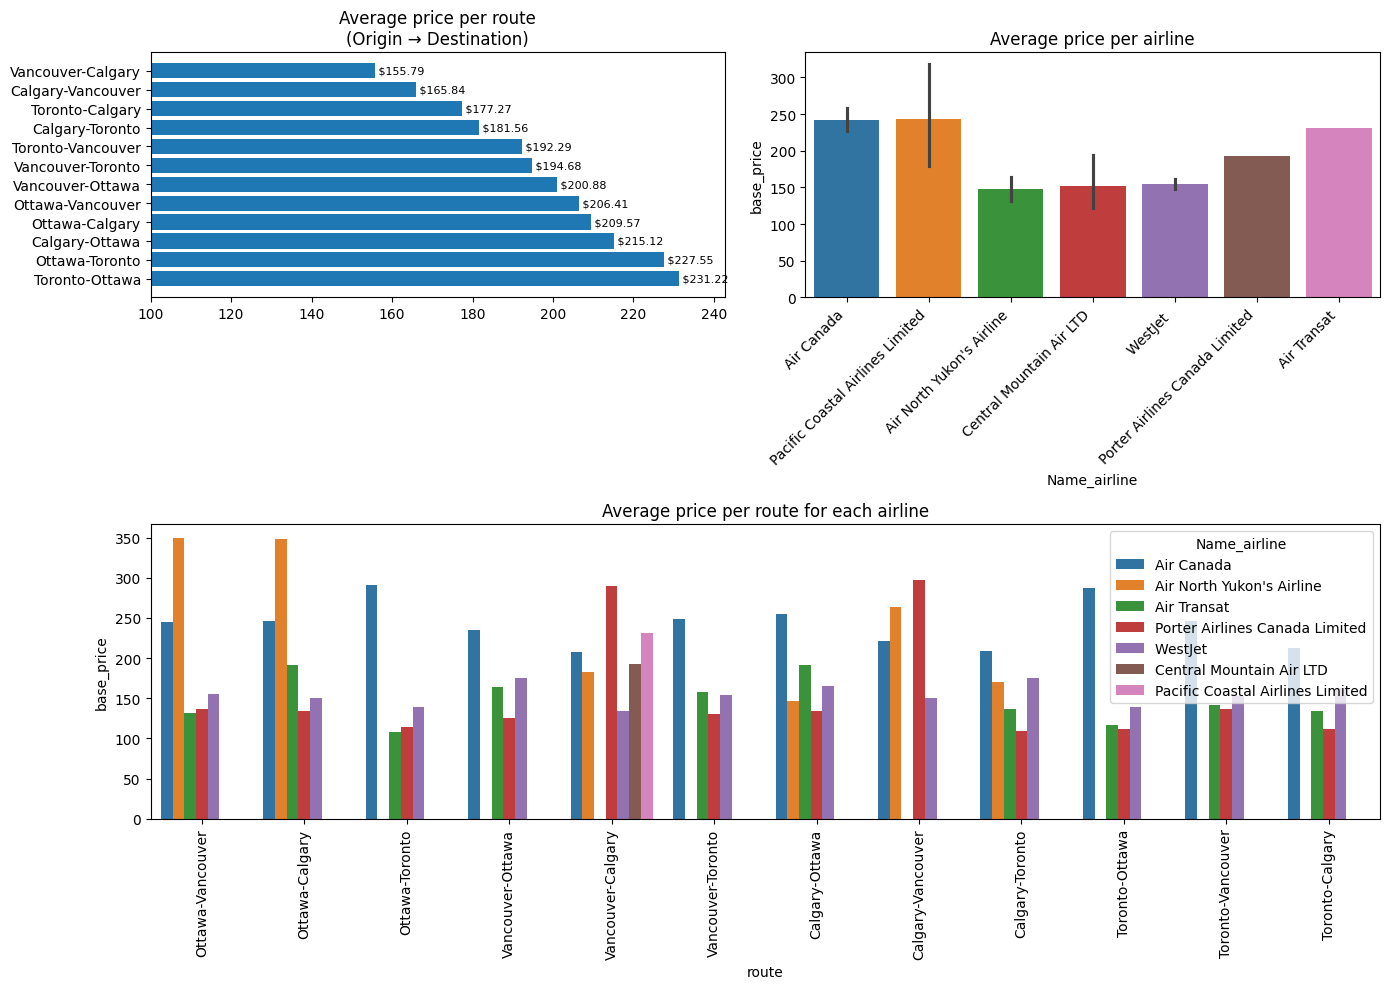

In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 
warnings.filterwarnings("ignore", category=UserWarning) 

route_sorted = route_df.sort_values('base_price', ascending=False)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# Top-left: average price per route (horizontal bars)
ax1 = fig.add_subplot(gs[0, 0])
ax1.barh(route_sorted['route'], route_sorted['base_price'])

for idx, val in enumerate(route_sorted['base_price']):
    ax1.text(val, idx, f' ${val:.2f}', ha='left', va='center', fontsize=8)

ax1.set_xlim(left = 100)
ax1.set_title('Average price per route\n(Origin → Destination)')

# Top-right: average price per airline
ax2 = fig.add_subplot(gs[0, 1])
airline_avg = df.groupby('Name_airline')['base_price'].mean().sort_values(ascending=False)
# ax2.bar(airline_avg.index, airline_avg.values)
sns.barplot(data=airline_route_price, x='Name_airline', y='base_price', hue='Name_airline', ax = ax2)
ax2.set_title('Average price per airline')
ax2.set_xticklabels(airline_avg.index, rotation=45, ha='right')

# Bottom (wide): average price per route for each airline
ax3 = fig.add_subplot(gs[1, :])
sns.barplot(
    data=airline_route_price,
    x='route',
    y='base_price',
    hue='Name_airline',
    ax=ax3
)
ax3.set_title('Average price per route for each airline')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show()

### 2. Price vs Days Until Departure (Very Important)
- How much does last-minute booking increase prices?
- Do prices increase as departure approaches (last-minute premium)?
- What is the optimal booking window for cheapest fares?
- Is there a "sweet spot" number of days ahead to buy?
- how many days till departure are prices the cheapest


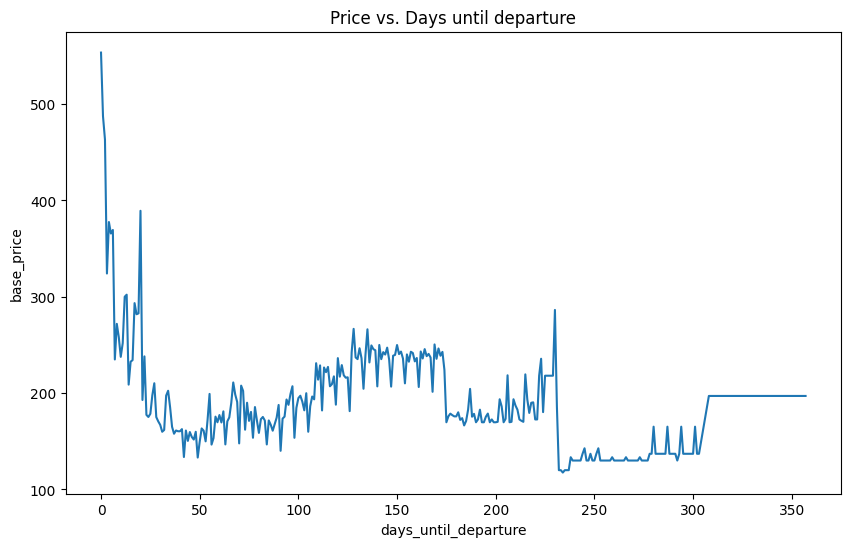

In [9]:
# how many days to departure date is the lowest price?
df_days = df.groupby('days_until_departure')['base_price'].mean().reset_index()

# show a line plot of average price by days until departure
plt.figure(figsize=(10,6))
sns.lineplot(data=df_days, x='days_until_departure', y='base_price')
plt.title('Price vs. Days until departure')
plt.show()

from the graph we can assume:
- prices are highest < 10 days until departure
- low price when you book 50 days till depature
- increase spike when we are 225 days till departure
- optimal window - good deal 40-120 days before departure

In [10]:
# average price by days until departure - how in 10 days bins

### 3a. Price by Time of Year

### 3. Price by Day of Week
- Which days are cheapest to fly?
- Do airlines offer more flights on high-demand days?
- Is weekend travel priced higher than weekday on domestic routes?


In [11]:
# which day of the week are cheapest to fly
df['day_of_week_departure'] = df['day_of_week_departure'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})
df.groupby('day_of_week_departure')['base_price'].agg(mean_price='mean', flight_count='count').reset_index()

,day_of_week_departure,mean_price,flight_count
0,Friday,213.332594,2706
1,Monday,213.688949,2588
2,Saturday,220.562151,2325
3,Sunday,188.840288,27869
4,Thursday,209.327160,2592
5,Tuesday,210.214344,2468
6,Wednesday,206.232656,2609


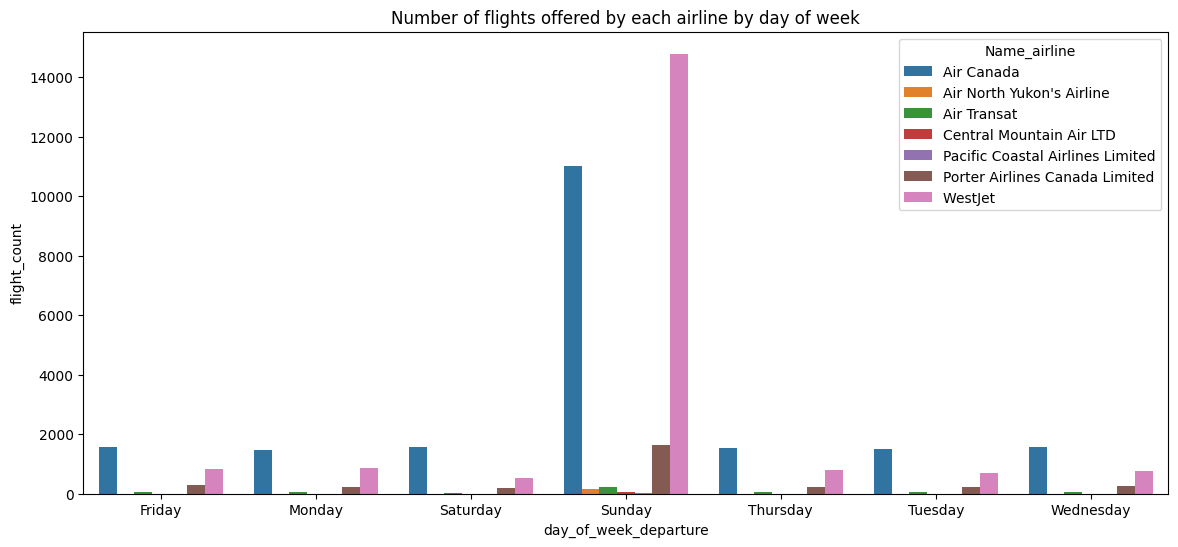

In [12]:
# number fo flight offered by each airline by day of week
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df.groupby(['Name_airline', 'day_of_week_departure'])['base_price'].agg(mean_price='mean', flight_count='count').reset_index(),
    hue='Name_airline',
    y='flight_count',
    x='day_of_week_departure',
)
plt.title('Number of flights offered by each airline by day of week')
plt.show()

- Sundays are cheapest days to fly and have the most flights

### 4. Price by Time of Day
- Are early morning or red-eye flights cheaper?
- Which departure windows are most expensive (peak demand times)?
- Do airlines price differently for business-hour vs. off-peak flights?


In [13]:
# normalize to datetime + hour DEPARTURE
df['departure_clock_time'] = pd.to_datetime(df['departure_clock_time'], format='%H:%M:%S').dt.time
df['departure_hour'] = pd.to_datetime(df['departure_clock_time'].astype(str), format='%H:%M:%S').dt.hour

# normalize to datetime + hour ARRIVAL
df['arrival_clock_time'] = pd.to_datetime(df['arrival_clock_time'], format='%H:%M:%S').dt.time
df['arrival_hour'] = pd.to_datetime(df['arrival_clock_time'].astype(str), format='%H:%M:%S').dt.hour

# map departure_clock_time to earling morning, morning, afternoon, evening, night
def slot_from_hour(h):
    if 0 <= h < 5:
        return 'Night'
    if 5 <= h < 8:
        return 'Early Morning'
    if 8 <= h < 12:
        return 'Morning'
    if 12 <= h < 17:
        return 'Afternoon'
    if 17 <= h < 21:
        return 'Evening'
    return 'Late Evening'

# apply function
df['departure_time_period'] = df['departure_hour'].apply(slot_from_hour)
df['arrival_time_period'] = df['arrival_hour'].apply(slot_from_hour)


In [14]:
# when is the best time of day to fly? (departure time) price by departure time
df.groupby('departure_time_period')['base_price'].agg(
    mean_price='mean',
    median_price='median',
    flight_count='count'
).reset_index()


,departure_time_period,mean_price,median_price,flight_count
0,Afternoon,201.092914,171.0,10203
1,Early Morning,171.366307,144.0,8613
2,Evening,213.780066,177.0,9712
3,Late Evening,182.832419,154.0,4374
4,Morning,204.744090,190.0,9730
5,Night,208.605714,178.0,525


earling morning flights between 5-8am departure time have the lowest price at about $171

In [15]:
# what is the best time to arrive at each destination? (arrival time) price by arrival time

arrival_stats = df.groupby(['arrival_time_period', 'City_destination'])['base_price'].agg(
    mean_price='mean',
    flight_count='count'
).reset_index()

# what is the best time to arrive at each destination? (arrival time) price by arrival time

departure_stats = df.groupby(['departure_time_period', 'City'])['base_price'].agg(
    mean_price='mean',
    flight_count='count'
).reset_index()

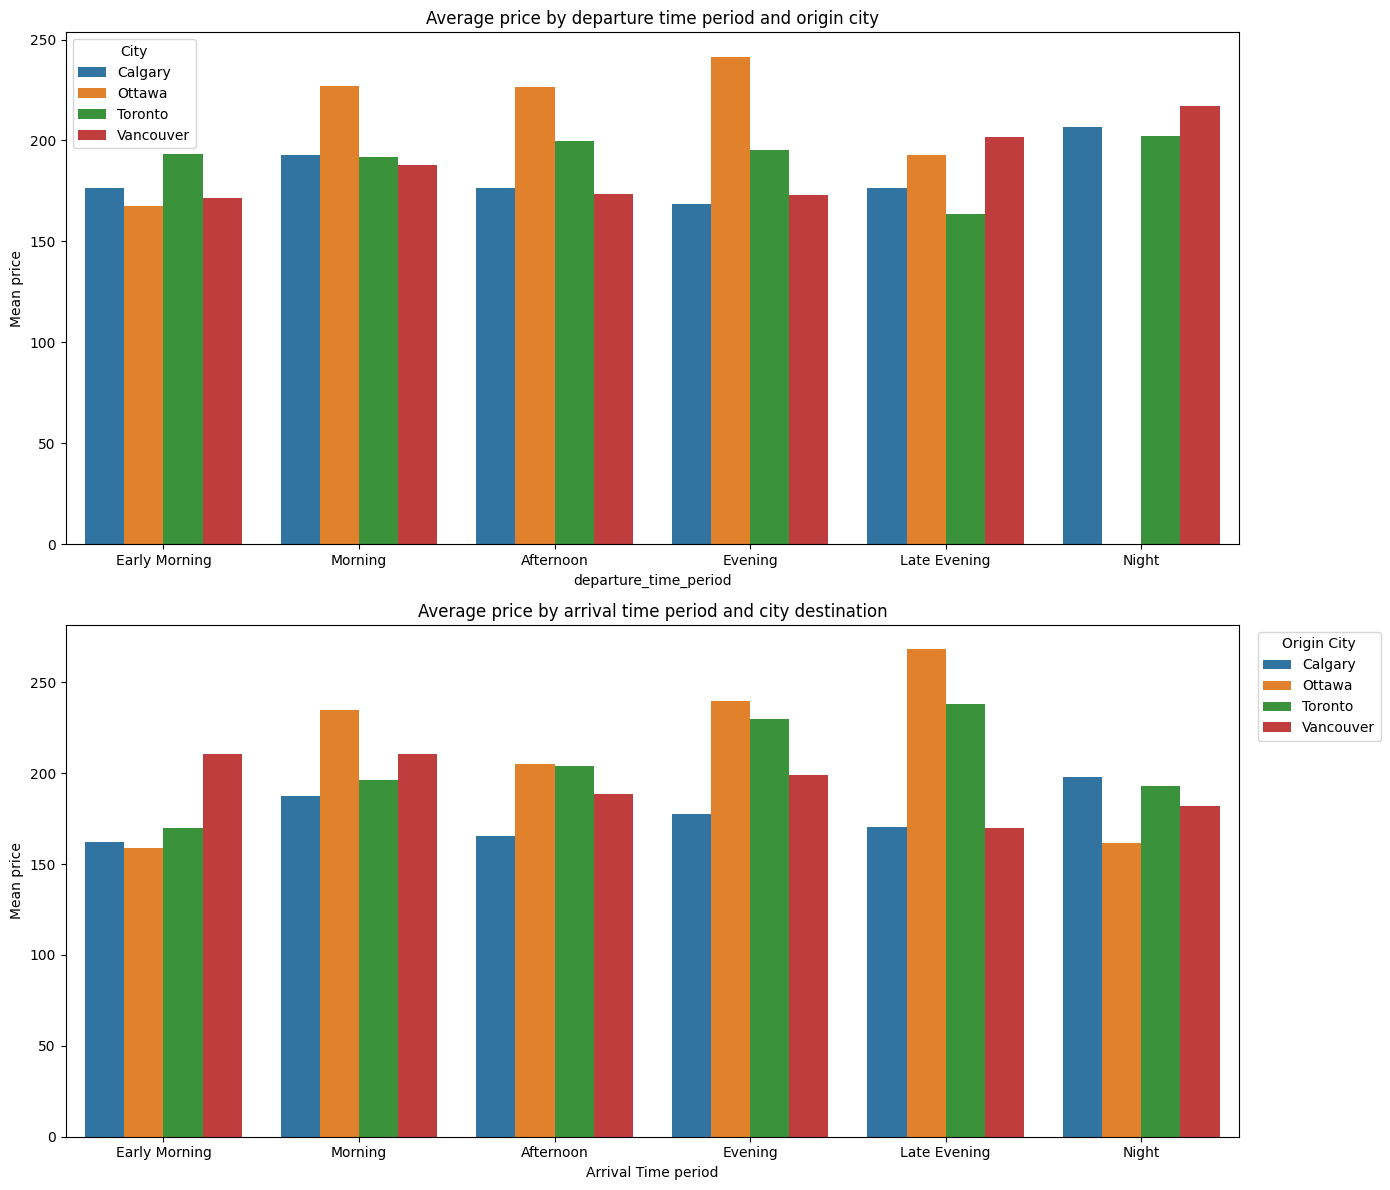

In [16]:
order = ['Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Evening', 'Night']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=False)

sns.barplot(
    data=arrival_stats,
    x='arrival_time_period',
    y='mean_price',
    hue='City_destination',
    order=order,
    ax=ax2
)
ax1.set_title('Average price by departure time period and origin city')
ax1.set_xlabel('')
ax1.set_ylabel('Mean price')
ax1.legend(title='Destination', bbox_to_anchor=(1.01, 1), loc='upper left')

sns.barplot(
    data=departure_stats,
    x='departure_time_period',
    y='mean_price',
    hue='City',
    order=order,
    ax=ax1
)
ax2.set_title('Average price by arrival time period and city destination')
ax2.set_xlabel('Arrival Time period')
ax2.set_ylabel('Mean price')
ax2.legend(title='Origin City', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5. Airline Pricing Strategy
- Which airline is cheapest on the same route?
- Do budget carriers (PD = Porter) consistently undercut legacy carriers (AC = Air Canada)?
- Is there a price-seat availability tradeoff — do cheaper flights have fewer seats left?


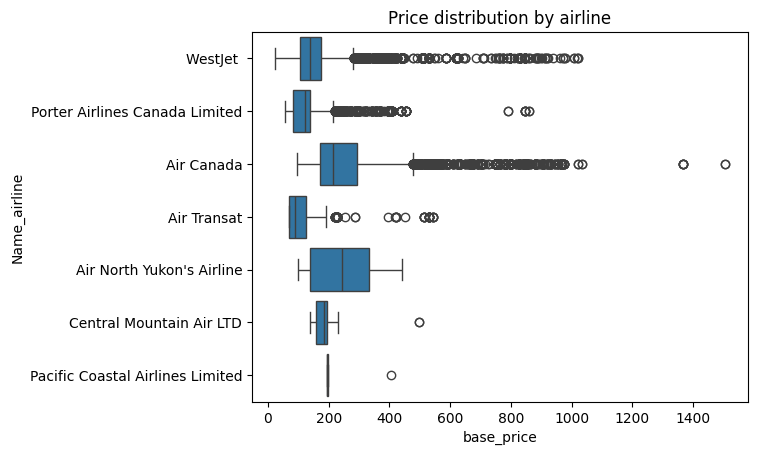

,Name_airline,mean_price,flight_count
0,Air Transat,126.219067,493
1,Porter Airlines Canada Limited,132.679868,3030
2,WestJet,154.316473,19237
3,Central Mountain Air LTD,192.385965,57
4,Air North Yukon's Airline,230.075949,158
5,Pacific Coastal Airlines Limited,230.666667,6
6,Air Canada,248.999504,20176


In [17]:
# 1. which airline offers the lowest average price?

# visualize the price distribution by airline
sns.boxplot(data = df, y = 'Name_airline', x = 'base_price')
plt.title('Price distribution by airline')
plt.show()

df.groupby('Name_airline')['base_price'].agg(mean_price = 'mean', flight_count = 'count').sort_values('mean_price').reset_index()


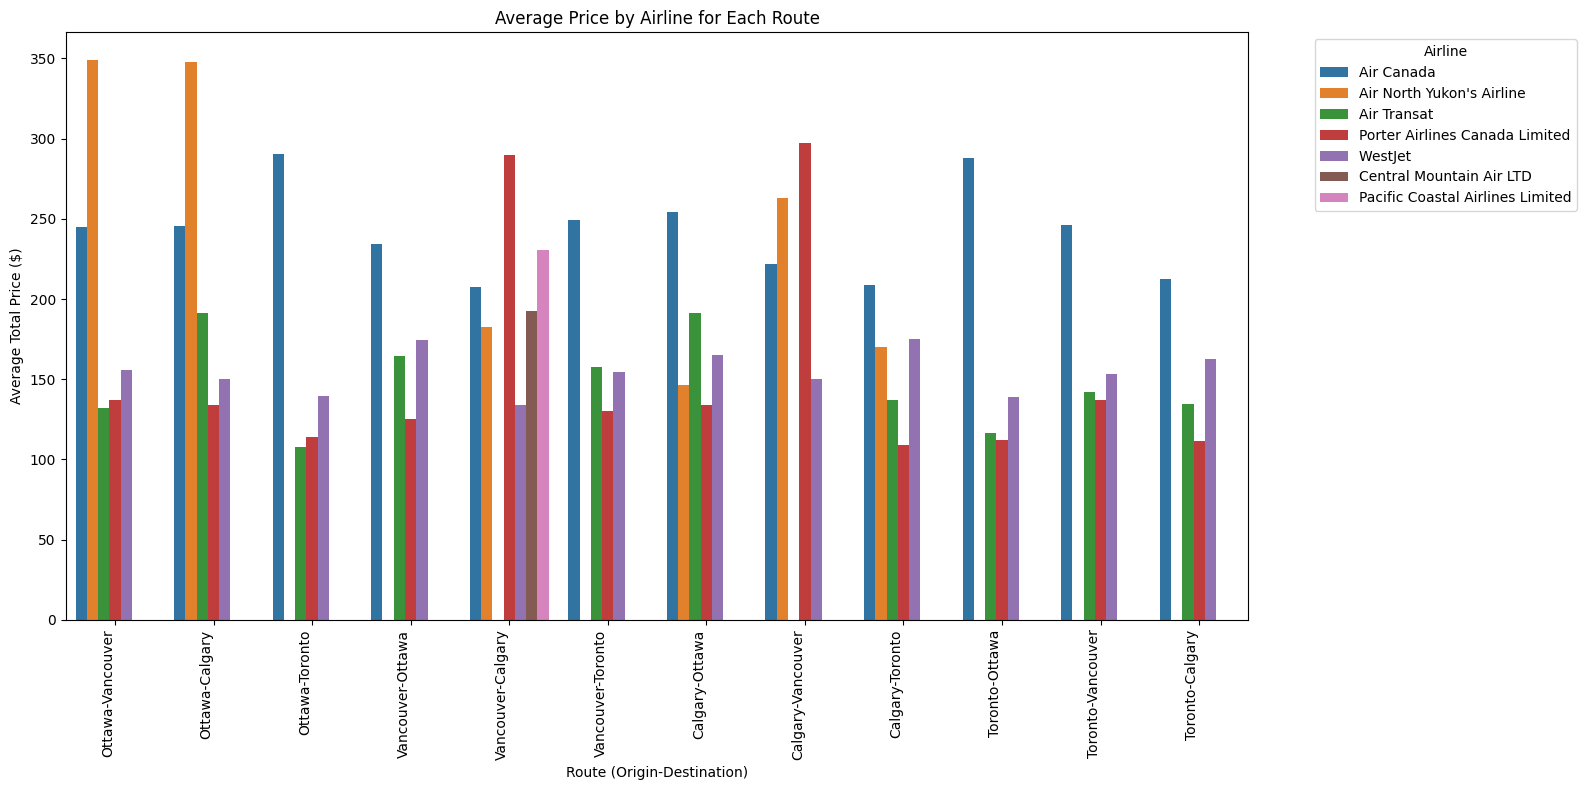

In [18]:
# 2. which airline is the cheapest based on route? (origin-destination pair)

plt.figure(figsize=(16, 8))
sns.barplot(
    data=airline_route_price,
    x='route',
    y='base_price',
    hue='Name_airline',
)
plt.xticks(rotation=90, ha='right')
plt.title('Average Price by Airline for Each Route')
plt.xlabel('Route (Origin-Destination)')
plt.ylabel('Average Total Price ($)')
plt.legend(title='Airline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# airline_route_price[['route','Name_airline','total_price']].sort_values(['route','total_price'], ascending=[True, True])


### 7. Flight Duration vs Price
- Do longer flights cost more?
- Are there fast premium flights?

Correlation between trip duration and base price: 0.1408846262150932


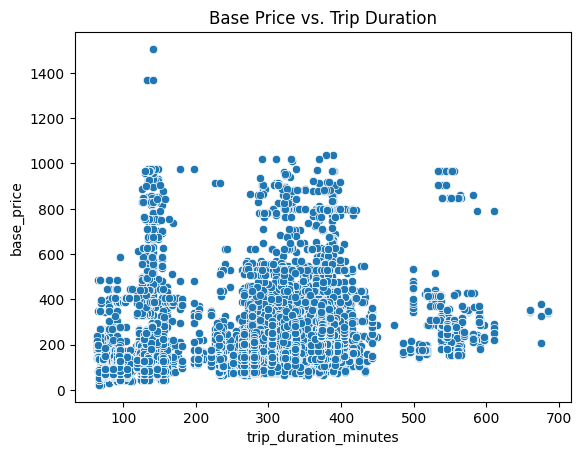

In [19]:
print('Correlation between trip duration and base price:', df['trip_duration_minutes'].corr(df['base_price']))

sns.scatterplot(data=df, x='trip_duration_minutes', y='base_price')
plt.title('Base Price vs. Trip Duration')
plt.show()

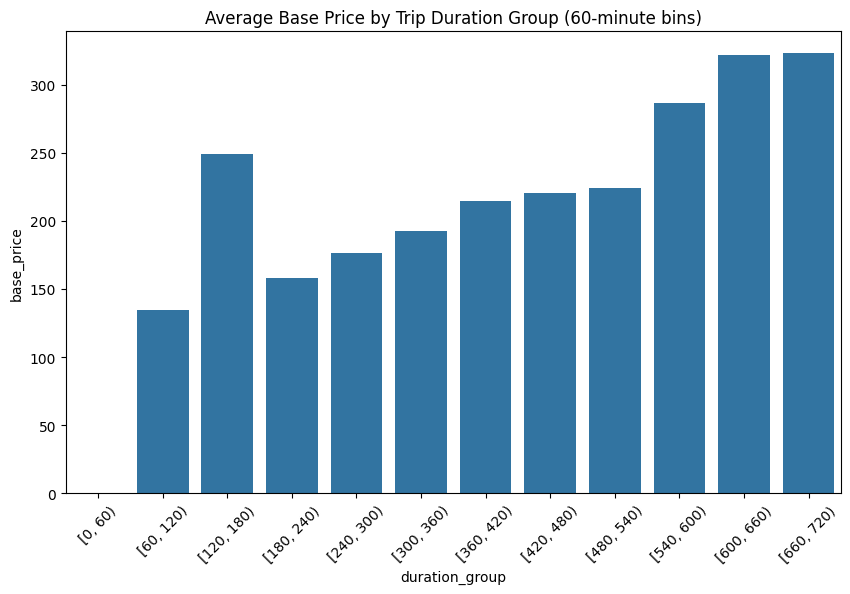

In [20]:
# Bin trip_duration_minutes into 60-minute intervals
bins = range(0, df['trip_duration_minutes'].max() + 60, 60)
df['duration_group'] = pd.cut(df['trip_duration_minutes'], bins=bins, right=False)

# Calculate average base_price for each duration group
avg_price_per_group = df.groupby('duration_group')['base_price'].mean().reset_index()

# Optional: Plot the average price per duration group
plt.figure(figsize=(10,6))
sns.barplot(data=avg_price_per_group, x='duration_group', y='base_price')
plt.title('Average Base Price by Trip Duration Group (60-minute bins)')
plt.xticks(rotation=45)
plt.show()

### 8. Stops vs Price
- How much cheaper are connecting flights vs direct flights?
- Are connecting flights cheaper than direct on the same route?
- At what price difference would a traveler prefer a layover?
- Do stops correlate with specific airlines or aircraft types?


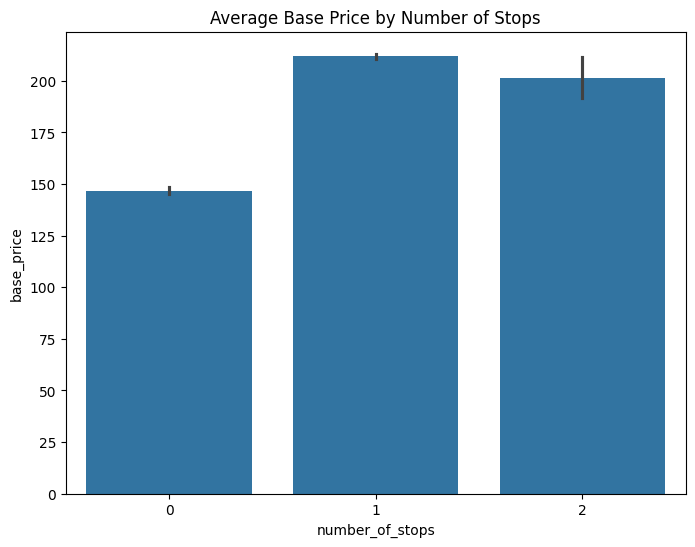

,number_of_stops,base_price
0,0,146.740366
1,1,211.887939
2,2,201.467456


In [21]:
# plot average price by number of stops 
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='number_of_stops', y='base_price')
plt.title('Average Base Price by Number of Stops')
plt.show()

df.groupby(['number_of_stops'])['base_price'].mean().reset_index()

### 9. Route-Level Analysis
- Which routes are most expensive per minute of travel?
- Which routes have high competition?
- Which routes have the most airline competition, and does competition lower prices?
- Are longer routes priced proportionally, or do short routes have disproportionate fares?
- Which origin-destination pairs have the least seat availability (capacity-constrained routes)?



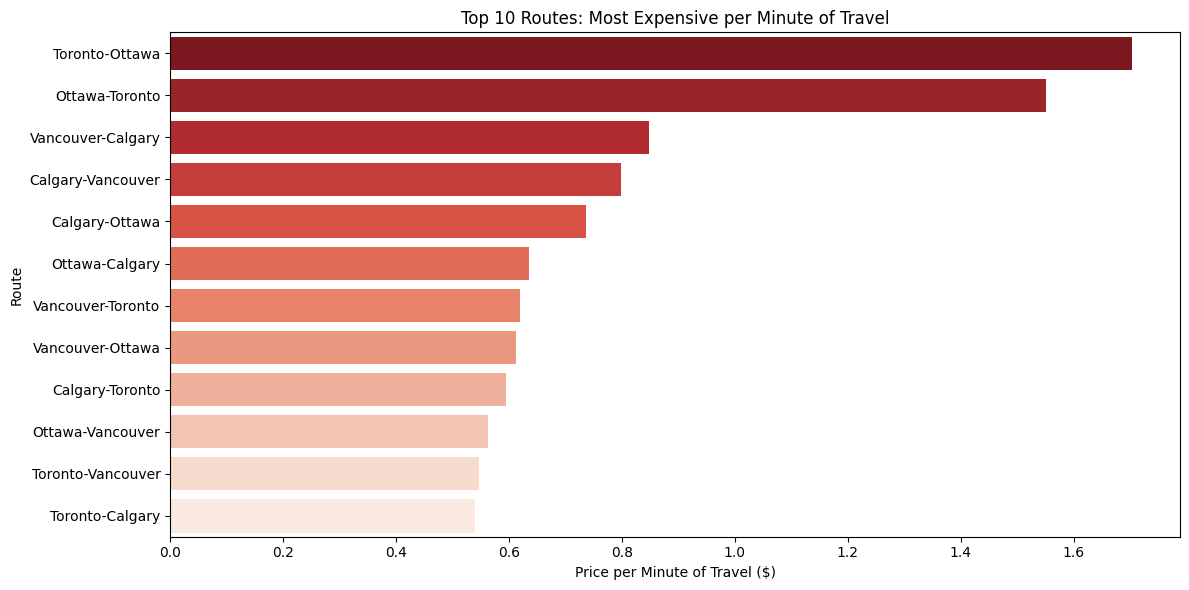

In [22]:
# Which routes are most expensive per minute of travel?

# avereage price per minute for each route
route_p_min = df.groupby(['origin','City','destination','City_destination']).agg(avg_price = ('base_price', 'mean'),
                                                                              avg_trip_duration_minutes = ('trip_duration_minutes', 'mean')
                                                                              ).reset_index()
route_p_min['price_per_minute'] = route_p_min['avg_price'] / route_p_min['avg_trip_duration_minutes']
route_p_min['route'] = route_p_min['City'] + '-' + route_p_min['City_destination']
route_p_min[['route','price_per_minute']].sort_values('price_per_minute', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=route_p_min.sort_values('price_per_minute', ascending=False), y='route', x='price_per_minute', palette='Reds_r')
plt.xlabel('Price per Minute of Travel ($)')
plt.ylabel('Route')
plt.title('Top 10 Routes: Most Expensive per Minute of Travel')
plt.tight_layout()
plt.show()

### 10. Bookable Seats

In [23]:
# does number of bookable seats affect the base price?
df.groupby(['bookable_seats'])['base_price'].agg(
    mean_price='mean',
    flight_count='count'
).reset_index()

,bookable_seats,mean_price,flight_count
0,1,261.515528,805
1,2,258.259901,404
2,3,281.950147,341
3,4,268.263889,648
4,5,253.281899,337
5,6,246.856716,335
6,7,153.508229,16040
7,8,248.844523,283
8,9,217.816850,23964


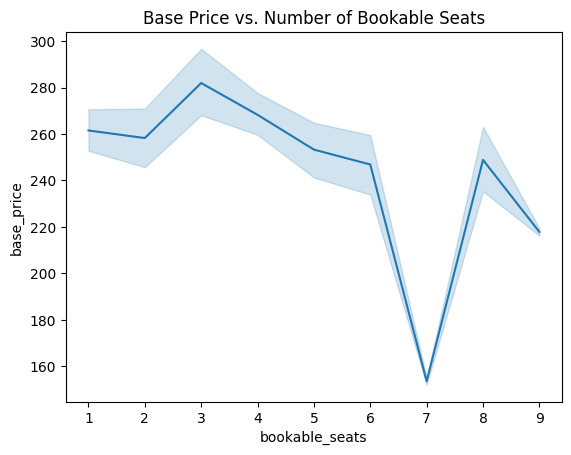

In [24]:
sns.lineplot(data=df, x='bookable_seats', y='base_price')
plt.title('Base Price vs. Number of Bookable Seats')
plt.show()

'7' and '9' bookable seats flight records are anomalies and can potentially skew our data, so we drop that column for model building.

In [25]:
df.drop('bookable_seats', axis=1, inplace=True)

In [32]:
# save dataframe
df.to_csv('../model_building/flights_eda_df.csv', index=False)

### EDA Steps
1. Correlation heatmap
- Calculated correlation matrix for numeric features in df.
- Visualized with seaborn heatmap (RdBu_r, annotated).
- Insights: which numeric variables co-move and potential multicollinearity signals.

2. Airline price distribution and outlier handling
- Plotted boxplot of total_price by Name_airline.
- Identified First Air Canadian North as outlier airlne (very small count, high skew).
- Dropped that airline from df to avoid undue influence on downstream modeling.

3. Route-level average pricing
- Computed route_df (origin/destination mean price and count).
- Computed airline_route_price (mean price by route+airline).
- Plotted summary figures:
    - average price per route,
    - average price per airline,
    - average price per route per airline.
- Found route-level pricing patterns and airline competitiveness.

4. Days until departure analysis
- Grouped by days_until_departure mean total_price.
- Line plot showed high last-minute prices (<10 days) and cheapest around 40-120 days out.

5. Day of week effects
- Converted day_of_week_departure to weekday names.
- Aggregated mean price and counts.
- Plotted airline flight counts by weekday.
- Observed cheapest day is Sunday (and generally high volume).

6. Time-of-day effects
- Created departure_hour/arrival_hour from clock times.
- Mapped periods with slot_from_hour.
- Aggregated mean/median prices by time period.
- Found early morning (5-8am) is cheapest, variations by origin/destination.

7. Airline pricing strategy
- Boxplot price distribution by airline.
- Summary stats for mean + count by airline.
- Route-level airline comparison plot from airline_route_price.
- Confirmed Porter/low-cost low mean, legacy carriers higher.

8. Flight duration vs price
- Correlation trip_duration_minutes vs base_price and total_price scatter.
- Binned trip_duration_minutes in 60-minute bins and plotted avg total_price.
- Noted longer flights mostly cost more, but non-linear behavior exists.

9. Stops vs price
- Barplot mean total_price by number_of_stops.
- Summary mean prices, check direct vs connecting dispersion.

10. Route-level per-minute pricing & competition
- Computed route_p_min (avg_price / avg_trip_duration).
- Plotted top most expensive routes per minute.
- Expanded competition_df with num_airlines, avg_price, competition_level.
- Found high-competition routes priced slightly lower than medium.

Overall: each EDA step produced both visual/Numeric confirmation of seasonal, route, airline, and temporal price dynamics; valuable for pricing strategy and predictive features.


### Summary

1. Correlation Heatmap:
Numeric features show moderate correlations; multicollinearity may exist between distance and duration, suggesting careful feature selection for modeling to avoid redundancy.

2. Airline Price Distribution and Outlier Handling:
First Air Canadian North is an outlier with high prices and low volume; removing it improves dataset reliability. Porter and Air Transat offer the lowest average prices, indicating budget carrier advantages.

3. Route-Level Average Pricing:
Routes like Toronto-Ottawa are most expensive; high-competition routes (5+ airlines) have slightly lower prices, suggesting competition drives down fares.

4. Price vs Days Until Departure:
Prices spike for last-minute bookings (<10 days); optimal booking window is 40-120 days ahead for lowest fares, enabling dynamic pricing strategies.

5. Day of Week Effects:
Sundays are cheapest and have highest flight volumes; airlines should consider increasing capacity or promotions on low-demand days like Wednesdays.

6. Time-of-Day Effects:
Early morning departures (5-8am) are cheapest; prices vary by origin/destination, with Vancouver arrivals being pricier in early morning, informing peak-hour surcharges.

7. Airline Pricing Strategy:
Porter consistently undercuts legacy carriers like Air Canada; budget airlines dominate low-price segments, recommending partnerships or fare matching for legacy carriers.

8. Flight Duration vs Price:
Longer flights generally cost more, but not linearly; binned analysis shows peaks around 540-600 minutes, suggesting premium for ultra-long hauls.

9. Stops vs Price:
Direct flights are cheapest; each stop increases price, but connecting flights offer cost savings for budget travelers, potentially increasing demand for layovers.

10. Route-Level Per-Minute Pricing:
Short routes like Toronto-Ottawa are most expensive per minute; high-competition routes lower prices, emphasizing competition's role in affordability.